# PISO algorithm implementation


## Modelo 

Solves the incompressible viscous Navier-Stokes equations.

Momentum Eq.: $\frac{\partial u}{\partial t} + (u.\nabla)u = -\frac{\nabla p}{\rho} + \nu \nabla^2u + f$

Incompressibility Eq.: $\nabla u = 0$


## Algorithm

Implementation of the PISO algoritm, similar to the icoFoam solver from  openFoam. 

$$\bold{M}.u^{n} = u^{n-1}/\Delta t -\nabla p = \bold{S} \qquad (1) $$

$$\bold{H} = \bold{A}.u^{n} - \bold{S} \qquad (2)$$

$$\nabla^2p = \bold{A}\nabla . (\bold{A}^{-1}\bold{H}) \qquad (3)$$

$$u^{n} = \bold{A}^{-1}\bold{H} - \bold{A}^{-1}\nabla p \qquad (4)$$

The PISO algorithm consists of an interation of the steps 1 -> 2 -> 3 -> 4 -> 2 -> ... apllied for both u and v components of the velocity, wich are solved independently, for each time step until convergence, then proceding to the next step.



# Code:

### Imports

In [68]:
import numpy as np
from matplotlib import pyplot as plt
import gmsh
import scipy.sparse as sp
import scipy.sparse.linalg as spla


### Constants

In [69]:
# Solver definitions 
RUN_TIME = 5
KINEMATIC_VISCOSITY = 0.0001
N_ITER_STEP = 250
TOLERANCE_ITER = 10**(-4)
DENSITY = 1.0
CFL = 1

# Under-relaxation factors
ALPHA_P = 0.3
ALPHA_U = 0.5
ALPHA_V = 0.5

# Advection scheme for the momentum convection term
# None (first-order upwind),"LimitedLinear", "Minmod", "vanLeer", "vanAlbada", "LinearUpwind"
ADVECTION_SCHEME = "LimitedLinear"


### Domain Definition

For the definition of the solution domain it is necessary to define both the mesh and the boundary conditions for the equations.

#### Mesh Generation

The mesh generation the library gmsh is used. The mesh can either be directly imported from a .msh file or generated from a .geo script. 

For the example a simple 2D airfoil (NACA 0012) was created. (Note: the current mesh does not represent good meshing practice)

#### Boundary conditions

To solve the equations on the domain it is important to define carefully the boundaries so to represent the physiscs of the problem, bad boundaries not only afect results but also solver stability.

In [70]:
# ---- Mesh definitions ----
class Face():
    def __init__(self, node_coords, owner_cell, neighbour_cell, boundary_name=None):
        self.nodes: np.ndarray = node_coords          # (2,2) endpoint coords of the edge
        self.owner_cell: "Cell" = owner_cell
        self.neighbour_cell: "Cell|None" = neighbour_cell   # None for boundary faces
        self.boundary_name: str|None = boundary_name

        self.face_center = node_coords.mean(axis=0)
        edge = node_coords[1] - node_coords[0]
        self.face_area = np.linalg.norm(edge)          # edge length (2D "area", unit depth)
        normal = np.array([edge[1], -edge[0]])
        normal /= np.linalg.norm(normal)
        # Orient outward from the owner cell
        if np.dot(normal, self.face_center - owner_cell.center) < 0:
            normal = -normal
        self.face_normal = normal

        if self.neighbour_cell is not None:
            d_own = np.dot(self.face_normal, self.face_center - self.owner_cell.center)
            d_nei = np.dot(self.face_normal, self.neighbour_cell.center - self.owner_cell.center)
            self.weight = d_own / d_nei
        else:
            self.weight = 1.0   # boundary face: value taken from owner cell + BC

    def flux_in_face(self):
        if self.neighbour_cell is not None:
            return (1 - self.weight) * self.owner_cell.value + self.weight * self.neighbour_cell.value
        return self.owner_cell.value


class Cell():
    def __init__(self, cell_id, node_coords, value=0.0):
        self.id = cell_id
        self.node_coords = node_coords      # (m,2) corner coordinates, ccw order (tri or quad)
        self.center = node_coords.mean(axis=0)
        x, y = node_coords[:, 0], node_coords[:, 1]
        self.volume = 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))  # shoelace
        self.faces: list[Face] = []
        self.value = value


class Mesh():
    def __init__(self):
        self.cells: list[Cell] = []
        self.faces: list[Face] = []

    def _build_from_gmsh(self):
        """Convert the CURRENT (already meshed) gmsh model into Cell/Face objects.

           - Reads triangles (type 2, 3 nodes) and quads (type 3, 4 nodes); 
           - The Cell/Face geometry (shoelace volume, outward-oriented face normals) is polygon-agnostic,
             so mixed tri/quad meshes work. 
           - Boundary faces are tagged with the name of the dim-1 physical group (curve) they belong to; 
           - Interior edges shared by two cells become internal faces. Call between gmsh meshing and gmsh.finalize().
        """
        # Node tag -> (x, y)
        node_tags, node_coords_flat, _ = gmsh.model.mesh.getNodes()
        coords = {tag: np.array(node_coords_flat[3*i:3*i+2]) for i, tag in enumerate(node_tags)}

        # Boundary edge (node pair) -> physical-group name, over ALL named dim-1 groups
        boundary_edges = {}
        for dim, tag in gmsh.model.getPhysicalGroups(1):
            name = gmsh.model.getPhysicalName(dim, tag)
            for ent in gmsh.model.getEntitiesForPhysicalGroup(dim, tag):
                etypes, _, enodes = gmsh.model.mesh.getElements(1, ent)
                for et, nodes in zip(etypes, enodes):
                    if et == 1:                              # 2-node line element
                        for a, b in nodes.reshape(-1, 2):
                            boundary_edges[frozenset((a, b))] = name

        # 2D volume elements: gather triangles then quads, each as a node-tag row
        elems = []
        for element_type, nodes_per in ((2, 3), (3, 4)):            # 2->tri, 3->quad
            tags = gmsh.model.mesh.getElementsByType(element_type)[1]
            if len(tags):
                elems.extend(tags.reshape(-1, nodes_per))

        # Cells (id = position in this list)
        self.cells = [Cell(i, np.array([coords[t] for t in el])) for i, el in enumerate(elems)]

        # Map each polygon edge to the cell(s) that own it
        edge_owners: dict = {}
        for cell, el in zip(self.cells, elems):
            m = len(el)
            for k in range(m):
                a, b = el[k], el[(k + 1) % m]
                edge_owners.setdefault(frozenset((a, b)), []).append((cell, a, b))

        # Build faces: 2 owners -> internal face; 1 owner -> boundary face
        for edge_key, owners in edge_owners.items():
            cell, a, b = owners[0]
            node_pair = np.array([coords[a], coords[b]])
            if len(owners) == 2:
                neighbour = owners[1][0]
                face = Face(node_pair, cell, neighbour)
                neighbour.faces.append(face)
            else:
                face = Face(node_pair, cell, None, boundary_name=boundary_edges.get(edge_key))
            cell.faces.append(face)
            self.faces.append(face)

    def import2DMesh(self, file):
        """Load a 2D mesh from a GMSH .geo or .msh file into Cell/Face objects.

           - A .msh file is used as-is; 
           - A .geo geometry is meshed here (generate(2));
           - Boundary faces are tagged by their dim-1 physical-group name, so define physical 
             curves in the file (e.g. "inlet", "outlet", "airfoil", "farfield") matching the 
             patch names used in the boundary-condition dicts;
        """
        gmsh.initialize()
        gmsh.open(file)
        if len(gmsh.model.mesh.getNodes()[0]) == 0:   # geometry only (e.g. a .geo) -> mesh it
            gmsh.model.mesh.generate(2)
            gmsh.model.mesh.recombine()
        self.cells, self.faces = [], []
        self._build_from_gmsh()
        gmsh.finalize()
        return self

    def generate2DQuadrilateralMeshGMSH(self, lx=1.0, ly=1.0, nx=30, ny=20):
        """Builds a structured quad mesh of a rectangle with GMSH.
           Physical groups: "bottom", "right", "top", "left"
        """
        # Initialize mesh
        gmsh.initialize()
        # initialize model
        gmsh.model.add("cavity")

        # Add geometric points
        p1 = gmsh.model.geo.addPoint(0, 0, 0)
        p2 = gmsh.model.geo.addPoint(lx, 0, 0)
        p3 = gmsh.model.geo.addPoint(lx, ly, 0)
        p4 = gmsh.model.geo.addPoint(0, ly, 0)

        # Add lines 
        l_bottom = gmsh.model.geo.addLine(p1, p2)
        l_right = gmsh.model.geo.addLine(p2, p3)
        l_top = gmsh.model.geo.addLine(p3, p4)
        l_left = gmsh.model.geo.addLine(p4, p1)

        # Create loop to bound surface
        loop = gmsh.model.geo.addCurveLoop([l_bottom, l_right, l_top, l_left])
        # Defines surface from created loop
        surface = gmsh.model.geo.addPlaneSurface([loop])

        # Transform lines in transfinite curves
        gmsh.model.geo.mesh.setTransfiniteCurve(l_bottom, nx + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_top, nx + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_left, ny + 1)
        gmsh.model.geo.mesh.setTransfiniteCurve(l_right, ny + 1)
        # Create surface mesh
        gmsh.model.geo.mesh.setTransfiniteSurface(surface)
        # Recombine triangle mesh to quad mesh
        gmsh.model.geo.mesh.setRecombine(2, surface)

        # Add physical groups to the models for boundary conditions
        gmsh.model.geo.synchronize()
        gmsh.model.addPhysicalGroup(1, [l_bottom], name="bottom")
        gmsh.model.addPhysicalGroup(1, [l_right], name="right")
        gmsh.model.addPhysicalGroup(1, [l_top], name="top")
        gmsh.model.addPhysicalGroup(1, [l_left], name="left")

        # Generates 2D mesh
        gmsh.model.mesh.generate(2)

        # Extract Cell/Face representation, then close gmsh
        self._build_from_gmsh()
        gmsh.finalize()
        return self

mesh = Mesh().import2DMesh("./mesh/airfoil.geo")   # or "path/to/geometry.geo"
print(f"Cells: {len(mesh.cells)}, Faces: {len(mesh.faces)}")
print(f"Total Volume: {sum([cell.volume for cell in mesh.cells])}")
print(f"Total Area: {sum([face.face_area for face in mesh.faces])}")

# ---- Boundary conditions ----
# Convention: 
# - Patch listed for a field is fixed value (Dirichlet); 
# - Patch omitted is zero gradient (Neumann). 
# Patches come from airfoil.geo: INLET, OUTLET, UPPER_WALL, LOWER_WALL, AIRFOIL.
#   INLET       : uniform freestream in            -> u=U, v=0 ; p zeroGradient
#   OUTLET      : outflow                          -> u,v zeroGradient ; p=0 fixedValue
#   UPPER/LOWER : far-field slip walls             -> v=0 (no penetration), u zeroGradient
#   AIRFOIL     : solid wall, no-slip              -> u=v=0 ; p zeroGradient
U_INF = 1.0
AOA = np.deg2rad(2)
u_boundary_values = {"INLET": U_INF * np.cos(AOA),
                     "UPPER_WALL": U_INF * np.cos(AOA), 
                     "LOWER_WALL": U_INF * np.cos(AOA), 
                     "AIRFOIL": 0.0}                    
v_boundary_values = {"INLET": U_INF * np.sin(AOA), 
                     "UPPER_WALL": U_INF * np.sin(AOA), 
                     "LOWER_WALL": U_INF * np.sin(AOA), 
                     "AIRFOIL": 0.0}  
p_boundary_values = {"OUTLET": 0.0}           # fixedValue-pressure outlet 



Info    : Reading './mesh/airfoil.geo'...
Info    : Reading './mesh/naca0012.geo'...
Info    : Done reading './mesh/naca0012.geo'
Info    : Done reading './mesh/airfoil.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 5 (Nurb)
Info    : [ 10%] Meshing curve 6 (Nurb)
Info    : [ 20%] Meshing curve 7 (Nurb)
Info    : [ 30%] Meshing curve 9 (Line)
Info    : [ 30%] Meshing curve 10 (Line)
Info    : [ 40%] Meshing curve 11 (Line)
Info    : [ 50%] Meshing curve 13 (Line)
Info    : [ 50%] Meshing curve 14 (Line)
Info    : [ 60%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 70%] Meshing curve 17 (Line)
Info    : [ 80%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [ 90%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Line)
Info    : Done meshing 1D (Wall 0.00224764s, CPU 0.002592s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 30%] Meshing surface 2 (Transfinite)
Info    :

In [71]:
def LimitedLinear(r):
    return min(2*r,1)

def Minmod(r):
    return min(r,1)

def vanLeer(r):
    return (r + abs(r))/(1 + abs(r))

def vanAlbada(r):
    return (r + r**2)/(1 + r**2)

def LinearUpwind(r):
    return min( 2*r, 0.5 * (r + 1), 2)


# Resolve the advection scheme selected in the config cell (ADVECTION_SCHEME) to its
# limiter function. None -> first-order upwind (no limiter / deferred correction).
ADVECTION_LIMITER = None if ADVECTION_SCHEME is None else globals()[ADVECTION_SCHEME]

### Matrix assembly

Functions to assemble the necessary matrixes for the solution of the problem.

In [72]:
def DiffusionMatrix(mesh, nu, boundary_values, field=None):
    """FV diffusion operator  -nu * div(grad u)  with per-patch BCs.

       Interior face uses the OVER-RELAXED non-orthogonal split of  S_f . grad(u):
           S_f = Delta_f + k_f,   Delta_f = (|S_f|^2 / (d.S_f)) d      (parallel to d)
           implicit:  a_f (u_P - u_N),   a_f = nu |S_f|^2 / (d.S_f)
           explicit (deferred): nu * k_f . grad(u)_f   -> source b
       On an orthogonal mesh  S_f || d  =>  a_f = nu|S_f|/|d|,  k_f = 0, reducing
       exactly to the previous operator (cavity result unchanged).
       field (+ its boundary_values) supplies the cell gradient for the correction;
       field=None -> pure orthogonal operator (old behaviour).

       Boundary patch (convention: name in boundary_values -> fixedValue; else zeroGradient):
           fixedValue u_b:  a_f = nu*|S_f|/|d_Pf|,  M[P,P]+=a_f,  b[P]+=a_f*u_b
           zeroGradient:    zero normal gradient -> no diffusive flux (no contribution)
    """
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    b = np.zeros(n)
    grad = CellGradient(mesh, field, boundary_values) if field is not None else None
    for f in mesh.faces:
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            Sf = f.face_area * f.face_normal              # owner-outward area vector
            d  = f.neighbour_cell.center - f.owner_cell.center
            dSf = np.dot(d, Sf)
            a = nu * np.dot(Sf, Sf) / dSf                 # over-relaxed implicit coeff
            rows += [P, P, N, N]
            cols += [P, N, N, P]
            vals += [a, -a, a, -a]
            if grad is not None:                          # deferred non-orthogonal correction
                k = Sf - (np.dot(Sf, Sf) / dSf) * d       # non-orthogonal part of S_f
                g = f.weight
                grad_f = (1 - g) * grad[P] + g * grad[N]  # interpolated face gradient
                corr = nu * np.dot(k, grad_f)
                b[P] += corr
                b[N] -= corr
        elif f.boundary_name in boundary_values:          # fixedValue (Dirichlet)
            d = np.linalg.norm(f.face_center - f.owner_cell.center)
            a = nu * f.face_area / d
            rows.append(P); cols.append(P); vals.append(a)
            b[P] += a * boundary_values[f.boundary_name]
        # else zeroGradient: no diffusive contribution
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return M, b
 

def DdtMatrix(mesh, dt, u_prev):     # u_prev: flat array indexed by cell.id
    n = len(mesh.cells)
    vols = np.array([c.volume for c in mesh.cells]) / dt
    M = sp.diags(vols).tocsr()
    b = vols * u_prev
    return M, b


def FaceFluxes(mesh, u, v, bv_u, bv_v):
    """Volumetric face flux  phi_f = S_f . u_f  for every face, owner-outward oriented.

       u, v: cell-centred arrays indexed by cell.id;  bv_*: {patch: value} for fixedValue.

       Interior face velocity is linearly interpolated with the face weight g.
       Boundary face: fixedValue patch (name in bv) uses the prescribed value; otherwise
       zeroGradient -> owner cell value (e.g. an outlet where velocity is not imposed).
    """
    phi = np.empty(len(mesh.faces))
    for k, f in enumerate(mesh.faces):
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            g = f.weight                       # neighbour weight (fraction toward N)
            uf = (1 - g) * u[P] + g * u[N]
            vf = (1 - g) * v[P] + g * v[N]
        else:
            name = f.boundary_name
            uf = bv_u[name] if name in bv_u else u[P]   # zeroGradient -> owner value
            vf = bv_v[name] if name in bv_v else v[P]
        phi[k] = f.face_area * (f.face_normal[0] * uf + f.face_normal[1] * vf)
    return phi


def ConvectionMatrix(mesh, phi, boundary_values, field=None, limiter=None):
    """FV advection operator  div(phi * Psi)  integrated over each cell.

       Implicit part is always UPWIND (bounded, diagonally dominant):
           interior face f (owner P, neighbour N), flux phi_f:
               M[P,P]+=max(phi,0), M[P,N]+=min(phi,0)
               M[N,N]+=max(-phi,0), M[N,P]+=min(-phi,0)
           boundary face (convention: name in boundary_values -> fixedValue Psi_b):
               outflow (phi>=0):                 Psi_f = Psi_P  -> M[P,P]+=phi
               inflow  + fixedValue:             Psi_f = Psi_b  -> b[P]-=phi*Psi_b
               inflow  + zeroGradient (outlet):  Psi_f = Psi_P  -> M[P,P]+=phi

       If `limiter` is given (a function r -> beta) with the current `field` Psi, a
       high-order TVD term is added by DEFERRED CORRECTION: the explicit anti-diffusive
       flux  phi * beta(r) * (Psi_linear - Psi_upwind)  is moved to the source b, so the
       linear system stays upwind/bounded. limiter=None -> pure upwind. The ratio uses
       the upwind-cell gradient:  r = max( 2 (d_CD . grad Psi_C)/(Psi_D - Psi_C) - 1, 0 ).
       Returns (M, b) with the term equal to  M @ Psi - b.
    """
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    b = np.zeros(n)
    grad = CellGradient(mesh, field, boundary_values) if limiter is not None else None
    for k, f in enumerate(mesh.faces):
        P = f.owner_cell.id
        ph = phi[k]
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            rows += [P, P, N, N]
            cols += [P, N, N, P]
            vals += [max(ph, 0.0), min(ph, 0.0), max(-ph, 0.0), min(-ph, 0.0)]
            if limiter is not None:
                C, D = (P, N) if ph >= 0.0 else (N, P)        # upwind C, downwind D
                denom = field[D] - field[C]
                if abs(denom) > 1e-12:
                    d_CD = mesh.cells[D].center - mesh.cells[C].center
                    r = max(2.0 * np.dot(d_CD, grad[C]) / denom - 1.0, 0.0)
                    g = f.weight
                    psi_lin = (1 - g) * field[P] + g * field[N]
                    dc = ph * limiter(r) * (psi_lin - field[C])  # deferred high-order flux
                    b[P] -= dc
                    b[N] += dc
        elif ph >= 0.0:                                   # outflow: Psi_f = Psi_P
            rows.append(P); cols.append(P); vals.append(ph)
        elif f.boundary_name in boundary_values:          # inflow, fixedValue: Psi_f = Psi_b
            b[P] -= ph * boundary_values[f.boundary_name]
        else:                                             # inflow, zeroGradient: Psi_f = Psi_P
            rows.append(P); cols.append(P); vals.append(ph)
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tocsr()
    return M, b


def CellGradient(mesh, field, boundary_values=None):
    """Green-Gauss cell-centred gradient:  grad(phi)_P = (1/V_P) sum_f phi_f * S_f,
       with S_f the outward (owner) face-area vector. Returns an (n_cells, 2) array.

       field: cell-centred array indexed by cell.id.
       boundary_values: {patch: value} for fixedValue boundary faces; if None or the
           patch is absent, the boundary face uses zero-gradient (phi_f = phi_owner).
    """
    n = len(mesh.cells)
    grad = np.zeros((n, 2))
    for f in mesh.faces:
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            g = f.weight
            phif = (1 - g) * field[P] + g * field[N]
        elif boundary_values is not None and f.boundary_name in boundary_values:
            phif = boundary_values[f.boundary_name]
        else:
            phif = field[P]                       # zero-gradient extrapolation
        Sf = f.face_area * f.face_normal          # outward from owner
        grad[P] += phif * Sf
        if f.neighbour_cell is not None:
            grad[N] -= phif * Sf                  # neighbour sees -S_f
    vols = np.array([c.volume for c in mesh.cells])
    return grad / vols[:, None]

# --- PISO-specific operators -------------------------------------------------
# The pressure step needs (a) the divergence of a face-flux field and (b) a
# variable-coefficient Laplacian: the corrected face flux is
#     phi^n_f = phiHbyA_f - (rAU/rho)_f |S_f|/d (p_N - p_P),
# so requiring sum_f phi^n_f = 0 gives  laplacian((rAU/rho), p) = div(phiHbyA).
# Using the rAU = V/A coefficient (instead of a constant one) is what makes the
# corrected flux actually divergence-free / avoids checkerboarding.

def Divergence(mesh, phi):
    """Integrated divergence per cell from a face-flux array:  sum_f phi_f (owner-outward)."""
    div = np.zeros(len(mesh.cells))
    for k, f in enumerate(mesh.faces):
        div[f.owner_cell.id] += phi[k]
        if f.neighbour_cell is not None:
            div[f.neighbour_cell.id] -= phi[k]
    return div


def PressureMatrixVar(mesh, coeff, bv_p=None, ref_cell=0):
    """Variable-coefficient pressure Laplacian for PISO (Eq. 3) with per-patch BCs.
       Assembles  sum_f c_f |S_f|/d (p_P - p_N)  with c_f the face-interpolated coeff
       (here coeff = rAU/rho per cell).

       Patch convention (name in bv_p -> fixedValue p_b; else zeroGradient):
           zeroGradient (Neumann) boundary face: no contribution.
           fixedValue  p_b:  a_b = coeff_P |S_f|/|d_Pf|,  M[P,P]+=a_b,
               boundary source  b_p[P]+=a_b*p_b  (added to the rhs by the caller).
       If NO fixedValue-p patch exists the operator is singular (all-Neumann), so the
       reference cell is pinned (p[ref]=0) and returned as `ref`; otherwise ref=None
       (a fixedValue patch, e.g. an outlet, already sets the pressure level).
       Returns (M, ref, b_p).
    """
    bv_p = bv_p or {}
    n = len(mesh.cells)
    rows, cols, vals = [], [], []
    b_p = np.zeros(n)
    has_dirichlet = False
    for f in mesh.faces:
        P = f.owner_cell.id
        if f.neighbour_cell is not None:
            N = f.neighbour_cell.id
            g = f.weight
            cf = (1 - g) * coeff[P] + g * coeff[N]
            d = np.linalg.norm(f.neighbour_cell.center - f.owner_cell.center)
            a = cf * f.face_area / d
            rows += [P, P, N, N]
            cols += [P, N, N, P]
            vals += [a, -a, a, -a]
        elif f.boundary_name in bv_p:                 # fixedValue p (e.g. outlet)
            has_dirichlet = True
            d = np.linalg.norm(f.face_center - f.owner_cell.center)
            a = coeff[P] * f.face_area / d
            rows.append(P); cols.append(P); vals.append(a)
            b_p[P] += a * bv_p[f.boundary_name]
        # else zeroGradient: no contribution
    M = sp.coo_matrix((vals, (rows, cols)), shape=(n, n)).tolil()
    if has_dirichlet:
        ref = None
    else:
        ref = ref_cell
        M[ref, :] = 0.0
        M[ref, ref] = 1.0                             # pin p[ref]=0 (all-Neumann case)
    return M.tocsr(), ref, b_p

### Algortihm execution


In [73]:
dt = np.max([face.face_area for face in mesh.faces]) * CFL / (U_INF)

n = len(mesh.cells)
vols = np.array([c.volume for c in mesh.cells])


# Cell-centred fields, flat arrays indexed by cell.id
u = np.zeros(n)
v = np.zeros(n)
p = np.zeros(n)

t = 0.0
history = []          # snapshots (t, u, v, p) captured each step for the evolution GIF
# ---- Outer time loop ----
while t < RUN_TIME:
    u_prev, v_prev = u.copy(), v.copy()          # u^{n-1} for the time derivative

    # Face flux from the current velocity; reused for u, v and all inner iterations
    phi = FaceFluxes(mesh, u, v, u_boundary_values, v_boundary_values)

    # (Eq. 1) Momentum operator  M = ddt + conv - nu*lap   (identical M for u and v;
    #          the BC source AND the deferred corrections differ per component, so
    #          convection AND diffusion are assembled separately for u and v: both the
    #          high-order advection limiter and the non-orthogonal diffusion correction
    #          are explicit and depend on the component field).
    Mddt, b_ddt_u = DdtMatrix(mesh, dt, u_prev)
    _,    b_ddt_v = DdtMatrix(mesh, dt, v_prev)
    Mconv, b_cv_u = ConvectionMatrix(mesh, phi, u_boundary_values, field=u_prev, limiter=ADVECTION_LIMITER)
    _,     b_cv_v = ConvectionMatrix(mesh, phi, v_boundary_values, field=v_prev, limiter=ADVECTION_LIMITER)
    Mdiff, b_df_u = DiffusionMatrix(mesh, KINEMATIC_VISCOSITY, u_boundary_values, field=u_prev)
    _,     b_df_v = DiffusionMatrix(mesh, KINEMATIC_VISCOSITY, v_boundary_values, field=v_prev)
    M  = (Mddt + Mconv + Mdiff).tocsr()
    Su = b_ddt_u + b_cv_u + b_df_u               # momentum source WITHOUT pressure gradient
    Sv = b_ddt_v + b_cv_v + b_df_v

    A = M.diagonal()
    Ainv = 1.0 / A
    Off = (M - sp.diags(A)).tocsr()              # off-diagonal (neighbour) coefficients
    rAUbyRho = (vols / A) / DENSITY              # rAU/rho :  V/A per cell, /rho

    # Pressure Laplacian is constant within the time step -> assemble & factor once.
    # ref is a pinned cell for all-Neumann pressure (None if a fixedValue patch exists);
    # b_p is the fixedValue-pressure boundary source added to the rhs.
    Lp, ref, b_p = PressureMatrixVar(mesh, rAUbyRho, p_boundary_values)
    Lp_solve = spla.splu(Lp.tocsc())
    M_solve  = spla.splu(M.tocsc())

    # (Eq. 1) Momentum predictor using the current pressure gradient
    gp = CellGradient(mesh, p, p_boundary_values)
    u = M_solve.solve(Su - vols * gp[:, 0] / DENSITY)
    v = M_solve.solve(Sv - vols * gp[:, 1] / DENSITY)

    # ---- Inner PISO corrector iterations ----
    for iter_step in range(1, N_ITER_STEP + 1):
        u_old, v_old, p_old = u.copy(), v.copy(), p.copy()

        # (Eq. 2) H = source - off-diagonal @ u ;  HbyA = A^-1 H
        Hu = Su - Off @ u
        Hv = Sv - Off @ v
        HbyA_u = Ainv * Hu
        HbyA_v = Ainv * Hv

        # (Eq. 3) Pressure:  laplacian(rAU/rho, p) = div(HbyA)
        phiHbyA = FaceFluxes(mesh, HbyA_u, HbyA_v, u_boundary_values, v_boundary_values)   # boundary flux from BCs
        rhs = -Divergence(mesh, phiHbyA) + b_p                   # + fixedValue-p boundary source
        if ref is not None:
            rhs[ref] = 0.0                                       # pin reference cell (all-Neumann)
        p_new = Lp_solve.solve(rhs)
        p = p_old + ALPHA_P * (p_new - p_old)                    # under-relax p

        # (Eq. 4) Correct velocity:  u = HbyA - (rAU/rho) grad(p)
        gp = CellGradient(mesh, p, p_boundary_values)
        u = u_old + ALPHA_U * ((HbyA_u - rAUbyRho * gp[:, 0]) - u_old)
        v = v_old + ALPHA_V * ((HbyA_v - rAUbyRho * gp[:, 1]) - v_old)

        u_residual = np.abs(u - u_old).sum()
        v_residual = np.abs(v - v_old).sum()
        p_residual = np.abs(p - p_old).sum()
        if u_residual < TOLERANCE_ITER and v_residual < TOLERANCE_ITER and p_residual < TOLERANCE_ITER:
            break

    div_max = np.abs(Divergence(mesh, FaceFluxes(mesh, u, v, u_boundary_values, v_boundary_values))).max()
    print(f"t={t + dt:.3f}  iters={iter_step:3d}  max|div|={div_max:.2e}  "
          f"u=[{u.min():+.2f},{u.max():+.2f}](Res: {u_residual:.2e})  v=[{v.min():+.2f},{v.max():+.2f}](Res: {u_residual:.2e})  p=[{p.min():+.2f},{p.max():+.2f}](Res: {p_residual:.2e})")
    t += dt
    history.append((t, u.copy(), v.copy(), p.copy()))   # snapshot for the GIF

t=0.028  iters= 48  max|div|=2.86e-02  u=[-0.13,+3.61](Res: 5.63e-06)  v=[-0.76,+0.85](Res: 5.63e-06)  p=[+0.42,+62.71](Res: 7.89e-05)
t=0.056  iters= 94  max|div|=5.93e-03  u=[+0.12,+4.12](Res: 5.78e-05)  v=[-0.35,+0.76](Res: 5.78e-05)  p=[-1.35,+4.67](Res: 9.20e-05)
t=0.085  iters= 80  max|div|=2.20e-03  u=[+0.17,+3.96](Res: 2.50e-05)  v=[-0.43,+0.85](Res: 2.50e-05)  p=[-0.17,+2.62](Res: 9.72e-05)
t=0.113  iters= 69  max|div|=1.47e-03  u=[+0.20,+3.55](Res: 4.53e-05)  v=[-0.47,+0.92](Res: 4.53e-05)  p=[-0.64,+1.18](Res: 9.02e-05)
t=0.141  iters= 63  max|div|=1.25e-03  u=[+0.21,+3.13](Res: 4.83e-05)  v=[-0.49,+0.96](Res: 4.83e-05)  p=[-0.55,+1.14](Res: 9.16e-05)
t=0.169  iters= 60  max|div|=1.17e-03  u=[+0.22,+2.77](Res: 2.50e-05)  v=[-0.50,+0.98](Res: 2.50e-05)  p=[-0.54,+1.05](Res: 9.39e-05)
t=0.197  iters= 55  max|div|=1.14e-03  u=[+0.21,+2.47](Res: 3.07e-05)  v=[-0.51,+0.98](Res: 3.07e-05)  p=[-0.53,+1.01](Res: 9.76e-05)
t=0.226  iters= 49  max|div|=1.13e-03  u=[+0.19,+2.22](Res: 3

### Results


In [74]:
# Imports airfoil
with open('mesh/naca0012.dat', 'r') as file:
    airfoil = np.array([[float(value) for value in line.strip().split(' ') if value!=''] for line in file.read().split('\n')[1:-1]])


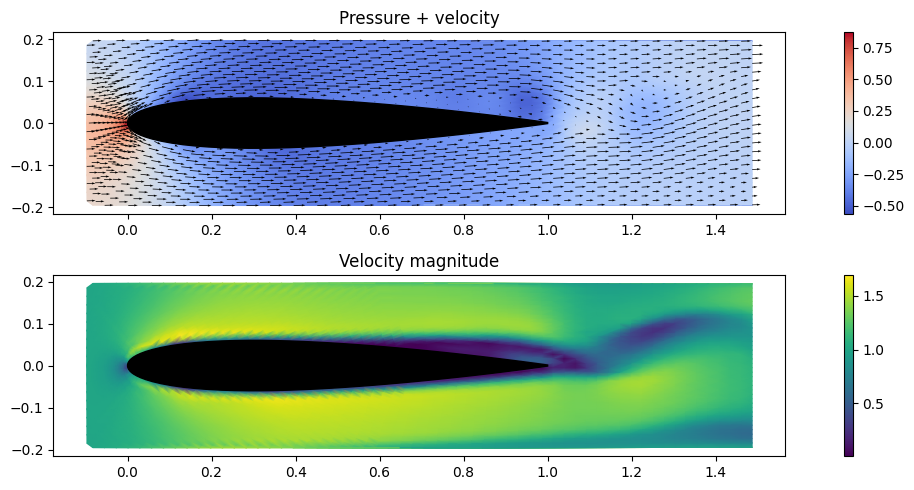

In [75]:
# Cell-centre coordinates for plotting the unstructured fields
xc = np.array([c.center[0] for c in mesh.cells])
yc = np.array([c.center[1] for c in mesh.cells])

fig, ax = plt.subplots(2, 1, figsize=(12, 5))

# Pressure field (filled, interpolated over the cell centres) + velocity vectors
tpc = ax[0].tripcolor(xc, yc, p, shading="gouraud", cmap="coolwarm")
ax[0].quiver(xc[::2], yc[::2], u[::2], v[::2], scale=85, width=0.001)
ax[0].set_title("Pressure + velocity")
ax[0].set_aspect("equal")
ax[0].fill(airfoil[:,0],  airfoil[:,1], color='k')
fig.colorbar(tpc, ax=ax[0])

# Velocity magnitude
speed = np.sqrt(u**2 + v**2)
spc = ax[1].tripcolor(xc, yc, speed, shading="gouraud", cmap="viridis")
ax[1].set_title("Velocity magnitude"); ax[1].set_aspect("equal")
ax[1].fill(airfoil[:,0],  airfoil[:,1], color='k')
fig.colorbar(spc, ax=ax[1])

plt.tight_layout()
# plt.savefig(f"./figs/{ADVECTION_SCHEME or 'Upwind'}.png")

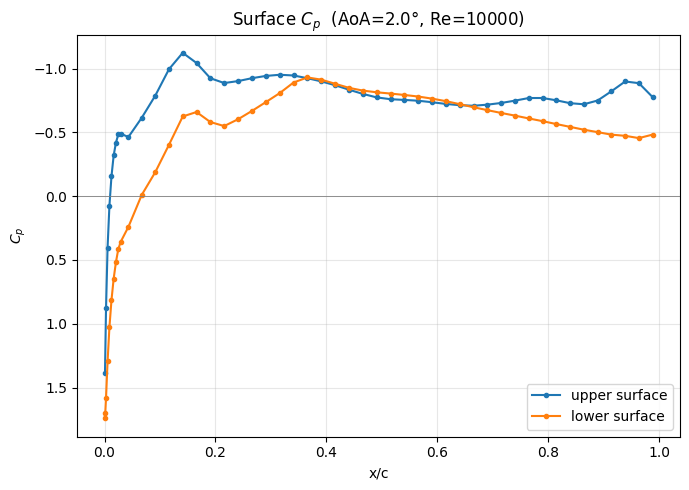

In [76]:
# ---- Surface pressure coefficient  Cp = (p - p_inf) / (0.5 rho U^2) ----
# Reference p_inf = 0
# Split upper/lower by surface side (y>=0 / y<0), sorted by x.
q_inf = 0.5 * DENSITY * U_INF**2
xu, cpu, xl, cpl = [], [], [], []
for f in mesh.faces:
    if f.neighbour_cell is None and f.boundary_name == "AIRFOIL":
        cp = p[f.owner_cell.id] / q_inf
        if f.face_center[1] >= 0:
            xu.append(f.face_center[0])
            cpu.append(cp)
        else:
            xl.append(f.face_center[0])
            cpl.append(cp)
iu, il = np.argsort(xu), np.argsort(xl)
xu, cpu = np.array(xu)[iu], np.array(cpu)[iu]
xl, cpl = np.array(xl)[il], np.array(cpl)[il]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xu, cpu, "-o", ms=3, label="upper surface")
ax.plot(xl, cpl, "-o", ms=3, label="lower surface")
ax.invert_yaxis()                      # aerodynamic convention: -Cp upward
ax.axhline(0, color="gray", lw=0.6)
ax.set_xlabel("x/c"); ax.set_ylabel(r"$C_p$")
ax.set_title(f"Surface $C_p$  (AoA={np.rad2deg(AOA):.1f}°, Re={U_INF/KINEMATIC_VISCOSITY:.0f})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

In [77]:
# ---- Animate the flow evolution (pressure + velocity magnitude) into a GIF ----
# Uses the `history` snapshots recorded during the time loop. Run the solver cell first.
import os
import matplotlib.animation as animation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
os.makedirs("./figs", exist_ok=True)

xc = np.array([c.center[0] for c in mesh.cells])
yc = np.array([c.center[1] for c in mesh.cells])

# Sub-sample so the GIF is at most ~60 frames, then fix colour scales across all frames
stride = max(1, len(history) // 60)
frames = history[::stride]
speed_all = np.concatenate([np.hypot(u_i, v_i) for _, u_i, v_i, _ in frames])
p_all     = np.concatenate([p_i for *_, p_i in frames])
pmin, pmax = np.percentile(p_all, [2, 98])
smax = np.percentile(speed_all, 98)

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
fig.colorbar(ScalarMappable(Normalize(pmin, pmax), cmap="coolwarm"), ax=ax[0], label="p")
fig.colorbar(ScalarMappable(Normalize(0.0, smax), cmap="viridis"),  ax=ax[1], label="|u|")

def draw(i):
    tt, u_i, v_i, p_i = frames[i]
    speed = np.hypot(u_i, v_i)
    for a in ax:
        a.clear()
    ax[0].tripcolor(xc, yc, p_i, shading="gouraud", cmap="coolwarm", vmin=pmin, vmax=pmax)
    ax[0].quiver(xc[::2], yc[::2], u_i[::2], v_i[::2], scale=85, width=0.001)
    ax[0].fill(airfoil[:, 0], airfoil[:, 1], color="k")
    ax[0].set_title(f"Pressure + velocity   t = {tt:.2f}"); ax[0].set_aspect("equal")
    ax[1].tripcolor(xc, yc, speed, shading="gouraud", cmap="viridis", vmin=0.0, vmax=smax)
    ax[1].fill(airfoil[:, 0], airfoil[:, 1], color="k")
    ax[1].set_title("Velocity magnitude"); ax[1].set_aspect("equal")

anim = animation.FuncAnimation(fig, draw, frames=len(frames), interval=100)
anim.save("./figs/flow_evolution.gif", writer="pillow", fps=10, dpi=90)
plt.close(fig)
print(f"saved ./figs/flow_evolution.gif  ({len(frames)} frames of {len(history)})")

saved ./figs/flow_evolution.gif  (89 frames of 178)
